# RL with GC Subgoal Proposer

Train a simple goal-conditioned MLP policy with offline imitation learning on a `GCDataset`.

In [1]:
from __future__ import annotations

from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax

from utils.datasets import GCDataset
from utils.flax_utils import TrainState, nonpytree_field
from utils.networks import ActorVectorField, MLP
from wrappers.datafuncs_utils import make_env_and_datasets


/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [2]:
config = dict(
    env_name='humanoidmaze-medium-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=5000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=25,
    discount=0.995
)

config

{'env_name': 'humanoidmaze-medium-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 5000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 25,
 'discount': 0.995}

In [3]:
class GCMLPPolicy(nn.Module):
    hidden_dims: tuple[int, ...]
    action_dim: int
    layer_norm: bool = True

    @nn.compact
    def __call__(self, observations, goals):
        x = jnp.concatenate([observations, goals], axis=-1)
        x = MLP(self.hidden_dims, activate_final=True, layer_norm=self.layer_norm)(x)
        x = nn.Dense(self.action_dim)(x)
        return x


class GCILAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def actor_loss(self, batch, grad_params=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']]
        pred_actions = self.network(observations, goals, params=grad_params)
        target_actions = batch[self.config['actions_key']]
        loss = jnp.mean(jnp.square(pred_actions - target_actions))
        mae = jnp.mean(jnp.abs(pred_actions - target_actions))
        return loss, {
            'loss': loss,
            'mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.actor_loss(batch, grad_params)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals):
        return self.network(observations, goals)

    @classmethod
    def create(cls, example_batch, config):
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = GCMLPPolicy(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            example_batch[config['goal_key']],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))


In [4]:
env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = GCDataset(base_train_dataset, config=config)

example_batch = train_dataset.sample(config['batch_size'])
print('env:', env.spec.id)
print('dataset keys:', sorted(base_train_dataset.keys()))
print('batch keys:', sorted(example_batch.keys()))
print(config['observations_key'] + ':', example_batch[config['observations_key']].shape)
print(config['goal_key'] + ':', example_batch[config['goal_key']].shape)
print(config['actions_key'] + ':', example_batch[config['actions_key']].shape)

env: humanoidmaze-medium-v0
dataset keys: ['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals']
batch keys: ['actions', 'actor_goals', 'low_actor_goals', 'masks', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'rewards', 'terminals', 'value_goals']
oracle_reps: (256, 2)
actor_goals: (256, 2)
low_actor_goals: (256, 2)


In [5]:
from tqdm import tqdm

all_cells = {}

for ob in tqdm(train_dataset.dataset['observations']):
    key = (np.floor(ob[0]), np.floor(ob[1]))
    if key in all_cells:
        all_cells[key] += 1
    else:
        all_cells[key] = 1

all_cell_points = np.asarray(list(all_cells.keys()))

100%|██████████| 2000000/2000000 [00:05<00:00, 338220.14it/s]


In [6]:
agent = GCILAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, agent.network.params)

{'Dense_0': {'bias': (2,), 'kernel': (256, 2)},
 'MLP_0': {'Dense_0': {'bias': (256,), 'kernel': (4, 256)},
  'Dense_1': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_2': {'bias': (256,), 'kernel': (256, 256)},
  'LayerNorm_0': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_1': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_2': {'bias': (256,), 'scale': (256,)}}}

In [7]:
loss_history = []
mae_history = []

for step in range(1, 100 * config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    agent, info = agent.update(batch)

    loss_history.append(float(info['loss']))
    mae_history.append(float(info['mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} loss={loss_history[-1]:.6f} mae={mae_history[-1]:.6f}"
        )


step=00001 loss=136.459106 mae=9.878541
step=00100 loss=12.301569 mae=2.647930
step=00200 loss=3.988369 mae=1.489994
step=00300 loss=1.538071 mae=0.954761
step=00400 loss=1.065799 mae=0.776327
step=00500 loss=0.779925 mae=0.697576
step=00600 loss=0.688814 mae=0.659445
step=00700 loss=0.733110 mae=0.684632
step=00800 loss=0.689540 mae=0.643787
step=00900 loss=0.624134 mae=0.615338
step=01000 loss=0.732878 mae=0.672690
step=01100 loss=0.733843 mae=0.639844
step=01200 loss=0.527107 mae=0.574419
step=01300 loss=0.566867 mae=0.591246
step=01400 loss=0.547429 mae=0.588797
step=01500 loss=0.692809 mae=0.645678
step=01600 loss=0.582161 mae=0.588615
step=01700 loss=0.551141 mae=0.592116
step=01800 loss=0.567784 mae=0.589521
step=01900 loss=0.622727 mae=0.618777
step=02000 loss=0.534104 mae=0.574485
step=02100 loss=0.756596 mae=0.672696
step=02200 loss=0.591522 mae=0.584889
step=02300 loss=0.589758 mae=0.603549
step=02400 loss=0.563729 mae=0.578032
step=02500 loss=0.607486 mae=0.613243
step=0260

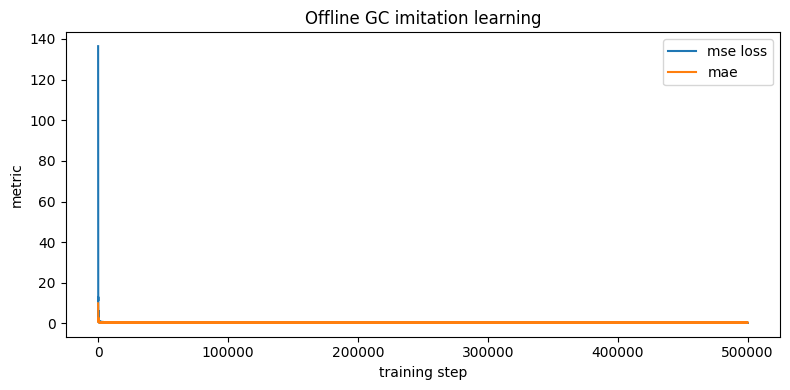

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, label='mse loss')
plt.plot(mae_history, label='mae')
plt.xlabel('training step')
plt.ylabel('metric')
plt.title('Offline GC imitation learning')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
eval_batch = train_dataset.sample(8)
pred_actions = np.asarray(
    agent.sample_actions(
        eval_batch[config['observations_key']],
        eval_batch[config['goal_key']],
    )
)
target_actions = np.asarray(eval_batch[config['actions_key']])

print('predicted actions shape:', pred_actions.shape)
print('target actions shape:', target_actions.shape)
print('sample mse:', np.mean((pred_actions - target_actions) ** 2))

predicted actions shape: (8, 2)
target actions shape: (8, 2)
sample mse: 0.32472584


In [10]:
from tqdm import tqdm

replay_buffer = []

# ob = np.asarray([0.0, 0.0])
ob = np.asarray([15.0, 20.0])
goal = np.asarray([0.0, 18.0])
print(ob.shape)
print(goal)

for _ in tqdm(range(2000)):
    replay_buffer.append(ob)
    subgoal = agent.sample_actions(ob, goal)
    ob = subgoal

(2,)
[ 0. 18.]


100%|██████████| 2000/2000 [00:00<00:00, 3813.60it/s]


In [11]:
replay_buffer

[array([15., 20.]),
 Array([15.128027, 19.684975], dtype=float32),
 Array([15.283773, 19.327024], dtype=float32),
 Array([15.4399  , 18.938143], dtype=float32),
 Array([15.591088, 18.554537], dtype=float32),
 Array([15.759371, 18.290983], dtype=float32),
 Array([15.962216, 18.180176], dtype=float32),
 Array([16.217386, 18.15896 ], dtype=float32),
 Array([16.539196, 18.186422], dtype=float32),
 Array([16.933691, 18.235575], dtype=float32),
 Array([17.391172, 18.27341 ], dtype=float32),
 Array([17.880713, 18.253084], dtype=float32),
 Array([18.354965, 18.123903], dtype=float32),
 Array([18.768017, 17.851173], dtype=float32),
 Array([19.10152 , 17.429426], dtype=float32),
 Array([19.347664, 16.855892], dtype=float32),
 Array([19.454348, 16.049242], dtype=float32),
 Array([19.415125, 15.029123], dtype=float32),
 Array([19.20345 , 13.954666], dtype=float32),
 Array([18.735514, 13.158064], dtype=float32),
 Array([17.950754, 12.742601], dtype=float32),
 Array([16.880924, 12.677471], dtype=flo

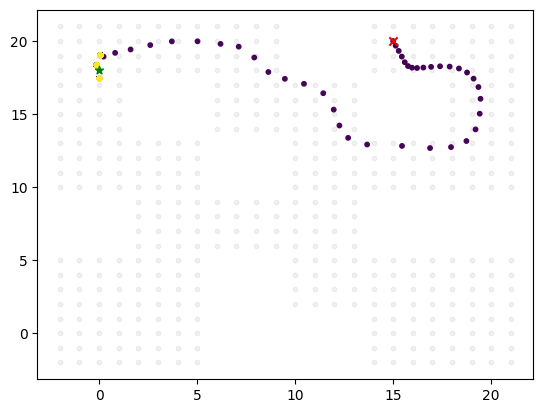

In [12]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')

Possible issue: if the subgoal agent is deterministic, there could be a fixed point.

(2,)
[ 5. 18.]


100%|██████████| 2000/2000 [00:00<00:00, 6442.86it/s]


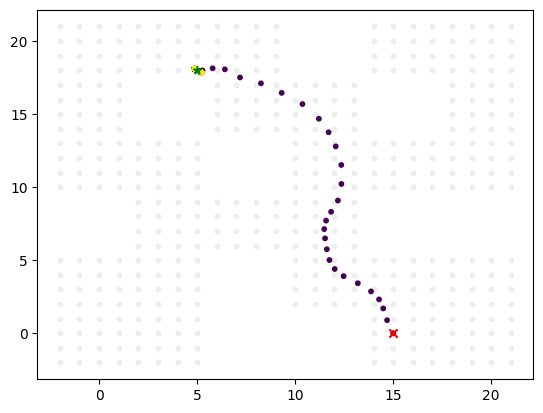

In [13]:
replay_buffer = []

# ob = np.asarray([0.0, 0.0])
ob = np.asarray([15.0, 0.0])
goal = np.asarray([5.0, 18.0])
print(ob.shape)
print(goal)

for _ in tqdm(range(2000)):
    replay_buffer.append(ob)
    subgoal = agent.sample_actions(ob, goal)
    ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')

## Using a Flow Network for the Proposer

In [14]:
config = dict(
    env_name='humanoidmaze-medium-navigate-v0',
    # dataset_path='../../scratch/aorl2/YOUR_RUN_DIR/data-1000000.npz',
    dataset_path='../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz',
    observations_key='oracle_reps', # 'observations',
    goal_key='actor_goals',
    actions_key='low_actor_goals', #'actions',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    batch_size=256,
    num_train_steps=5000,
    log_interval=100,
    seed=0,
    value_p_curgoal=0.0,
    value_p_trajgoal=1.0,
    value_p_randomgoal=0.0,
    value_geom_sample=False,
    actor_p_curgoal=0.0,
    actor_p_trajgoal=1.0,
    actor_p_randomgoal=0.0,
    actor_geom_sample=True,
    gc_negative=False,
    subgoal_steps=25,
    discount=0.995,
    flow_steps=10,
)

config

{'env_name': 'humanoidmaze-medium-navigate-v0',
 'dataset_path': '../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'actions_key': 'low_actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'batch_size': 256,
 'num_train_steps': 5000,
 'log_interval': 100,
 'seed': 0,
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'subgoal_steps': 25,
 'discount': 0.995,
 'flow_steps': 10}

In [15]:
from utils.networks import ActorVectorField

In [16]:
class GCFlowGoalProposerAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def flow_loss(self, batch, grad_params=None, rng=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']]
        target_actions = batch[self.config['actions_key']]

        batch_size, action_dim = target_actions.shape
        rng = self.rng if rng is None else rng
        x_rng, t_rng = jax.random.split(rng)

        x_0 = jax.random.normal(x_rng, (batch_size, action_dim))
        t = jax.random.uniform(t_rng, (batch_size, 1))
        x_t = (1.0 - t) * x_0 + t * target_actions
        vel = target_actions - x_0

        pred_vel = self.network(
            observations,
            goals=goals,
            actions=x_t,
            times=t,
            params=grad_params,
        )
        loss = jnp.mean(jnp.square(pred_vel - vel))
        mae = jnp.mean(jnp.abs(pred_vel - vel))
        return loss, {
            'flow_loss': loss,
            'velocity_mae': mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, rng = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.flow_loss(batch, grad_params, rng=rng)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals, rng):
        single_example = observations.ndim == 1
        if single_example:
            observations = observations[None, ...]
            goals = goals[None, ...]

        x = jax.random.normal(rng, (observations.shape[0], self.config['action_dim']))

        for i in range(self.config['flow_steps']):
            t = jnp.full((observations.shape[0], 1), i / self.config['flow_steps'])
            vels = self.network(observations, goals=goals, actions=x, times=t)
            x = x + vels / self.config['flow_steps']

        return x[0] if single_example else x

    @classmethod
    def create(cls, example_batch, config):
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = ActorVectorField(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            goals=example_batch[config['goal_key']],
            actions=example_batch[config['actions_key']],
            times=example_batch[config['actions_key']][..., :1],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        config = dict(config)
        config['action_dim'] = action_dim
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))

In [17]:
flow_agent = GCFlowGoalProposerAgent.create(example_batch, config)
jax.tree_util.tree_map(lambda x: x.shape, flow_agent.network.params)

{'mlp': {'Dense_0': {'bias': (256,), 'kernel': (7, 256)},
  'Dense_1': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_2': {'bias': (256,), 'kernel': (256, 256)},
  'Dense_3': {'bias': (2,), 'kernel': (256, 2)},
  'LayerNorm_0': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_1': {'bias': (256,), 'scale': (256,)},
  'LayerNorm_2': {'bias': (256,), 'scale': (256,)}}}

In [25]:
flow_loss_history = []
velocity_mae_history = []

for step in range(1, 100 * config['num_train_steps'] + 1):
    batch = train_dataset.sample(config['batch_size'])
    flow_agent, info = flow_agent.update(batch)

    flow_loss_history.append(float(info['flow_loss']))
    velocity_mae_history.append(float(info['velocity_mae']))

    if step == 1 or step % config['log_interval'] == 0:
        print(
            f"step={step:05d} flow_loss={flow_loss_history[-1]:.6f} velocity_mae={velocity_mae_history[-1]:.6f}"
        )


step=00001 flow_loss=0.912867 velocity_mae=0.728624
step=00100 flow_loss=0.983518 velocity_mae=0.754950
step=00200 flow_loss=0.949203 velocity_mae=0.767878
step=00300 flow_loss=0.898476 velocity_mae=0.710600
step=00400 flow_loss=0.849626 velocity_mae=0.709169
step=00500 flow_loss=0.864192 velocity_mae=0.710825
step=00600 flow_loss=0.983024 velocity_mae=0.770492
step=00700 flow_loss=1.021078 velocity_mae=0.783534
step=00800 flow_loss=0.995960 velocity_mae=0.766195
step=00900 flow_loss=0.871726 velocity_mae=0.712584
step=01000 flow_loss=0.944250 velocity_mae=0.758992
step=01100 flow_loss=0.815865 velocity_mae=0.685979
step=01200 flow_loss=0.982158 velocity_mae=0.755677
step=01300 flow_loss=1.096850 velocity_mae=0.796439
step=01400 flow_loss=0.884876 velocity_mae=0.731950
step=01500 flow_loss=0.897066 velocity_mae=0.724249
step=01600 flow_loss=0.968458 velocity_mae=0.768200
step=01700 flow_loss=0.915345 velocity_mae=0.743659
step=01800 flow_loss=0.907339 velocity_mae=0.735348
step=01900 f

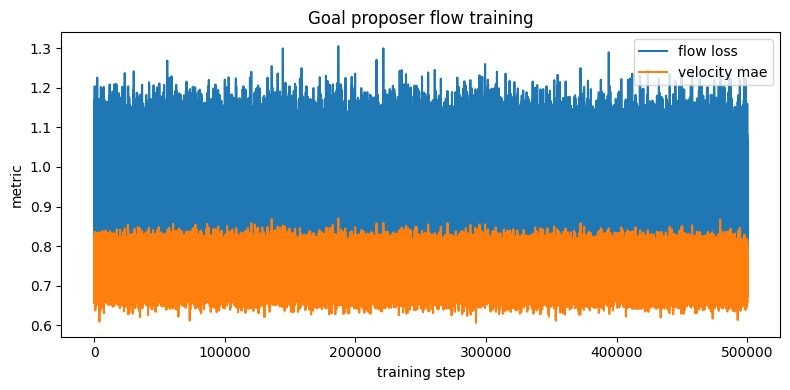

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(flow_loss_history, label='flow loss')
plt.plot(velocity_mae_history, label='velocity mae')
plt.xlabel('training step')
plt.ylabel('metric')
plt.title('Goal proposer flow training')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
eval_batch = train_dataset.sample(8)
rng = jax.random.PRNGKey(config['seed'])
rng, sample_rng = jax.random.split(rng)
pred_subgoals = np.asarray(
    flow_agent.sample_actions(
        eval_batch[config['observations_key']],
        eval_batch[config['goal_key']],
        sample_rng,
    )
)
target_subgoals = np.asarray(eval_batch[config['actions_key']])

print('predicted subgoals shape:', pred_subgoals.shape)
print('target subgoals shape:', target_subgoals.shape)
print('sample mse:', np.mean((pred_subgoals - target_subgoals) ** 2))

predicted subgoals shape: (8, 2)
target subgoals shape: (8, 2)
sample mse: 1.0815245


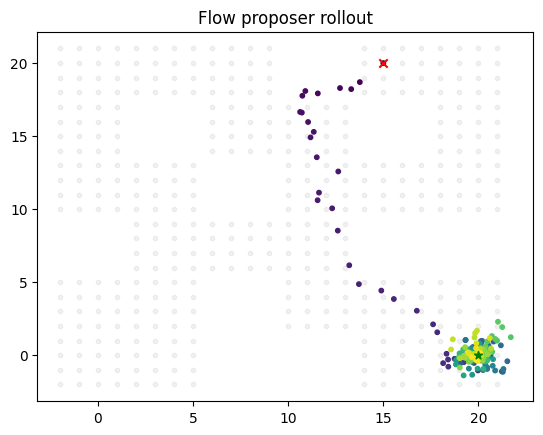

In [34]:
replay_buffer = []
ob = np.asarray([15.0, 20.0])
goal = np.asarray([20.0, 0.0])
rng = jax.random.PRNGKey(config['seed'])

for s in range(200):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

It cheats — doesn't actually obey reachability constraints.

(2,)
[20.  0.]


100%|██████████| 2000/2000 [00:00<00:00, 6583.52it/s]


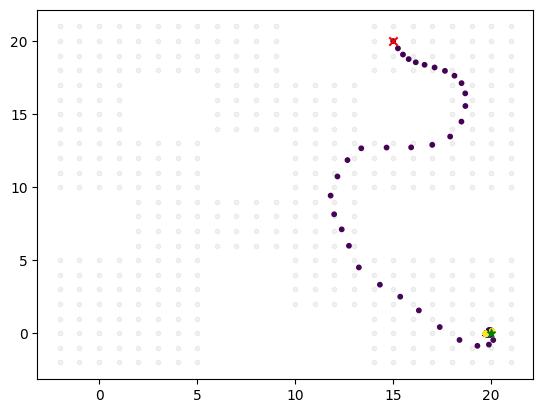

In [29]:
replay_buffer = []

# ob = np.asarray([0.0, 0.0])
ob = np.asarray([15.0, 20.0])
goal = np.asarray([20.0, 0.0])
print(ob.shape)
print(goal)

for _ in tqdm(range(2000)):
    replay_buffer.append(ob)
    subgoal = agent.sample_actions(ob, goal)
    ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')

In [24]:
100 * config['num_train_steps']

500000

## Get GCFQL Agent Checkpoint

In [23]:
AGENT_CHECKPOINT = '../../scratch/aorl2/2026-03-16-00/2026-03-16-00.0dfb77fdff1e9bb91c8f7575c8ad2c3f7d867f93572cfb2780acc46d86598233/'
CKPT_NUM = 1000000

In [24]:
import glob
import json
from pathlib import Path

from agents import agents
from utils.datasets import GCDataset, HGCDataset
from utils.flax_utils import restore_agent

In [25]:
checkpoint_dir = Path(AGENT_CHECKPOINT).expanduser()
with open(checkpoint_dir / 'flags.json', 'r') as f:
    saved_flags = json.load(f)

dataset_path = checkpoint_dir / f'data-{CKPT_NUM}.npz'
if not dataset_path.exists():
    dataset_dir = saved_flags.get('dataset_dir')
    if dataset_dir is None:
        raise FileNotFoundError(f'Could not find {dataset_path} and no dataset_dir in flags.json')
    dataset_candidates = [
        file for file in sorted(glob.glob(f"{dataset_dir}/*.npz")) if '-val.npz' not in file
    ]
    if not dataset_candidates:
        raise FileNotFoundError(f'No dataset files found in {dataset_dir}')
    dataset_path = Path(dataset_candidates[0])

gcfql_config = saved_flags['agent']
seed = saved_flags.get('seed', 0)
env_name = saved_flags['env_name']

env, base_train_dataset, _ = make_env_and_datasets(
    env_name,
    dataset_path=str(dataset_path),
    use_oracle_reps=True,
)
dataset_class = {
    'GCDataset': GCDataset,
    'HGCDataset': HGCDataset,
}[gcfql_config['dataset_class']]
restored_train_dataset = dataset_class(base_train_dataset, gcfql_config)
example_batch = restored_train_dataset.sample(1)

gcfql_agent = agents[gcfql_config['agent_name']].create(seed, example_batch, gcfql_config)
gcfql_agent = restore_agent(gcfql_agent, str(checkpoint_dir), CKPT_NUM)



Restored from ../../scratch/aorl2/2026-03-16-00/2026-03-16-00.0dfb77fdff1e9bb91c8f7575c8ad2c3f7d867f93572cfb2780acc46d86598233/params_1000000.pkl


In [26]:
rollout_steps = 250
task_id = 1
rng = jax.random.PRNGKey(seed)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

traj_obs = [np.asarray(observation)]
traj_actions = []
traj_rewards = []

for step in tqdm(range(rollout_steps)):
    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=goal, seed=action_rng))
    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))
    traj_actions.append(action)
    traj_rewards.append(reward)
    traj_obs.append(np.asarray(next_observation))
    observation = next_observation
    if terminated or truncated:
        print(f'rollout ended at step {step + 1}')
        break

traj_obs = np.asarray(traj_obs)
traj_actions = np.asarray(traj_actions)
traj_rewards = np.asarray(traj_rewards)

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('total reward:', float(traj_rewards.sum()) if len(traj_rewards) else 0.0)
print('last info:', info)

  0%|          | 0/250 [00:00<?, ?it/s]

100%|██████████| 250/250 [00:02<00:00, 119.35it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
total reward: -250.0
last info: {'xy': array([16.47278257, 18.68990343]), 'prev_qpos': array([16.42253034, 18.66315131,  0.65915822,  0.70703275, -0.09086231,
        0.51533031,  0.47569255,  0.58398764, -0.28949026,  0.59800422,
        0.09314814, -0.66727619, -0.55502752,  0.04323346, -0.61131539,
        0.88350146,  0.09494183,  0.45429106, -1.05301219, -1.66661571,
       -0.8806658 ,  0.88168582, -1.57368331, -0.54008922,  0.88136498,
       -0.18778936,  0.0552252 ,  0.88055704]), 'prev_qvel': array([ 2.28630088e+00,  1.01069895e+00, -3.41015719e+00,  3.57971257e+00,
        2.89435222e+00, -4.62711754e-01,  5.52375323e+00,  2.73941640e+00,
       -3.43518117e-01,  1.85192665e-01, -1.20662483e+00, -5.48773678e+00,
       -1.52256598e-01, -3.22054093e+00,  7.61074580e-02, -1.3931684

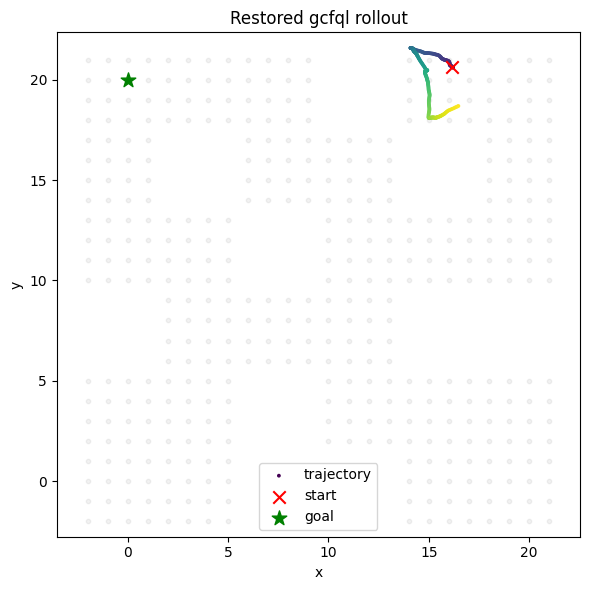

In [27]:
if traj_obs.shape[-1] >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
    plt.scatter(traj_obs[:, 0], traj_obs[:, 1], marker='o', s=3, label='trajectory', cmap='viridis', c=np.arange(len(traj_obs)))
    plt.scatter(traj_obs[0, 0], traj_obs[0, 1], c='red', marker='x', s=80, label='start')
    plt.scatter(goal[0], goal[1], c='green', marker='*', s=120, label='goal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Restored gcfql rollout')
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Observation does not have at least 2 dims to plot.')

## Checking subgoals

In [28]:
from wrappers.datafuncs_utils import to_oracle_reps

In [29]:
rollout_steps = 250
task_id = 1
rng = jax.random.PRNGKey(seed)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

traj_obs = [np.asarray(observation)]
traj_actions = []
traj_rewards = []
proposed_subgoals = []

for step in tqdm(range(rollout_steps)):
    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=goal, seed=action_rng))

    rng, sample_rng = jax.random.split(rng)
    subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))
    traj_actions.append(action)
    traj_rewards.append(reward)
    traj_obs.append(np.asarray(next_observation))
    proposed_subgoals.append(subgoal)
    observation = next_observation
    if terminated or truncated:
        print(f'rollout ended at step {step + 1}')
        break

traj_obs = np.asarray(traj_obs)
traj_actions = np.asarray(traj_actions)
traj_rewards = np.asarray(traj_rewards)
proposed_subgoals = np.asarray(proposed_subgoals)

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('total reward:', float(traj_rewards.sum()) if len(traj_rewards) else 0.0)
print('last info:', info)

100%|██████████| 250/250 [00:05<00:00, 48.50it/s] 


restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
total reward: -250.0
last info: {'xy': array([18.18615684, 18.86760463]), 'prev_qpos': array([ 1.81603577e+01,  1.88673480e+01,  5.51254267e-01, -1.12641134e-01,
        3.68719958e-03, -3.25550448e-01, -9.38783940e-01,  3.35225836e-01,
        4.54112590e-01, -5.39428233e-01, -5.13148033e-01, -9.38482054e-01,
       -1.30404142e+00,  4.36087067e-02,  1.40334656e-01, -9.64341940e-01,
       -1.84249219e-01, -7.76779132e-01, -1.84002726e+00, -2.72836704e+00,
       -6.98139658e-01,  8.68010255e-01,  1.44415147e-01, -1.07055242e+00,
       -4.47714761e-01, -1.05512378e+00, -1.10245217e+00,  8.88211002e-01]), 'prev_qvel': array([ 7.30531870e-01, -1.93376912e-01,  1.08241258e+00, -3.21117856e+00,
       -2.69704369e-01,  9.92755196e-01,  3.66911660e+00,  1.37886173e+00,
       -2.76040572e+00, 

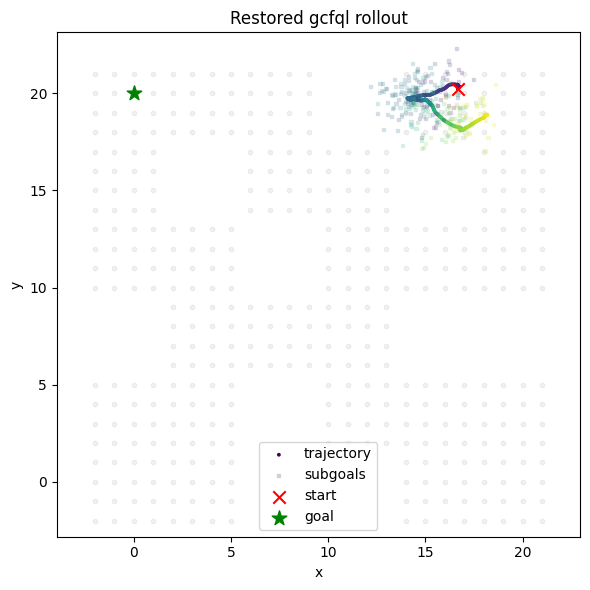

In [30]:
if traj_obs.shape[-1] >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
    plt.scatter(traj_obs[:, 0], traj_obs[:, 1], marker='o', s=3, label='trajectory', cmap='viridis', c=np.arange(len(traj_obs)))
    plt.scatter(proposed_subgoals[:, 0], proposed_subgoals[:, 1], marker='s', alpha=0.15, s=5, label='subgoals', cmap='viridis', c=np.arange(len(proposed_subgoals)))
    plt.scatter(traj_obs[0, 0], traj_obs[0, 1], c='red', marker='x', s=80, label='start')
    plt.scatter(goal[0], goal[1], c='green', marker='*', s=120, label='goal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Restored gcfql rollout')
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Observation does not have at least 2 dims to plot.')

In [31]:
rollout_steps = 250
task_id = 1
rng = jax.random.PRNGKey(seed)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

traj_obs = [np.asarray(observation)]
traj_actions = []
traj_rewards = []
proposed_subgoals = []

for step in tqdm(range(rollout_steps)):
    rng, sample_rng = jax.random.split(rng)
    subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))

    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))
    traj_actions.append(action)
    traj_rewards.append(reward)
    traj_obs.append(np.asarray(next_observation))
    proposed_subgoals.append(subgoal)
    observation = next_observation
    if terminated or truncated:
        print(f'rollout ended at step {step + 1}')
        break

traj_obs = np.asarray(traj_obs)
traj_actions = np.asarray(traj_actions)
traj_rewards = np.asarray(traj_rewards)
proposed_subgoals = np.asarray(proposed_subgoals)

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('total reward:', float(traj_rewards.sum()) if len(traj_rewards) else 0.0)
print('last info:', info)

100%|██████████| 250/250 [00:01<00:00, 150.90it/s]


restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
total reward: -250.0
last info: {'xy': array([17.62129504, 19.33111412]), 'prev_qpos': array([ 1.75627682e+01,  1.92980079e+01,  1.21518939e+00, -1.53320193e-01,
        4.54428050e-02, -1.90265859e-01,  9.68621068e-01,  4.37173803e-01,
       -4.86452779e-01,  2.30744449e-01,  8.92120930e-02, -9.33071064e-01,
        1.67023572e-01,  8.73807332e-02,  9.32085553e-02,  2.05267804e-01,
        4.45789247e-02, -6.37375901e-01, -2.16962187e-01,  4.20071578e-02,
        7.46558889e-01,  7.53325054e-01,  1.33411192e-02,  4.27386967e-01,
        7.83130960e-01, -6.96093034e-01, -1.05447625e+00,  8.81531937e-01]), 'prev_qvel': array([ 2.28195619e+00,  1.20575935e+00,  4.41850174e-01,  2.66807676e-01,
        2.38305518e+00, -5.69302064e+00,  9.49059763e-01,  4.07354048e-01,
        2.37339113e+00, 

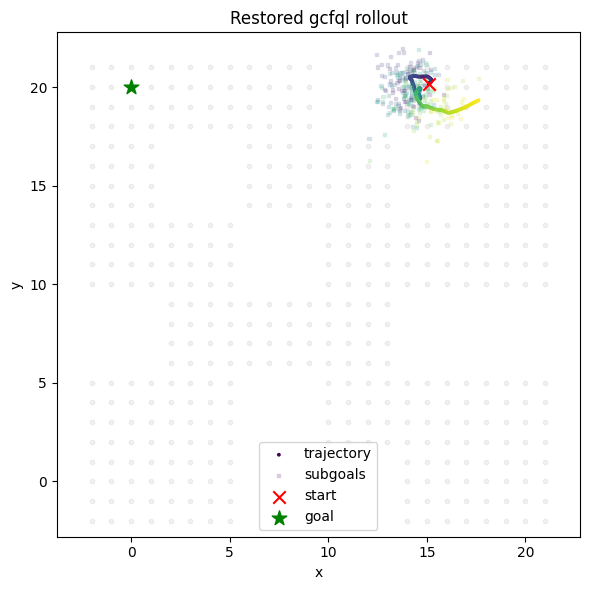

In [32]:
if traj_obs.shape[-1] >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
    plt.scatter(traj_obs[:, 0], traj_obs[:, 1], marker='o', s=3, label='trajectory', cmap='viridis', c=np.arange(len(traj_obs)))
    plt.scatter(proposed_subgoals[:, 0], proposed_subgoals[:, 1], marker='s', alpha=0.15, s=5, label='subgoals', cmap='viridis', c=np.arange(len(proposed_subgoals)))
    plt.scatter(traj_obs[0, 0], traj_obs[0, 1], c='red', marker='x', s=80, label='start')
    plt.scatter(goal[0], goal[1], c='green', marker='*', s=120, label='goal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Restored gcfql rollout')
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Observation does not have at least 2 dims to plot.')

## What is more likely to make it out of the bottleneck?

In [33]:
rollout_steps = 250
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0

rng = jax.random.PRNGKey(seed)

for trial in tqdm(range(num_trials)):
    rng, _ = jax.random.split(rng)
    observation, info = env.reset(options=dict(task_id=task_id))
    goal = info.get('goal')
    if goal is None:
        raise ValueError('Environment reset did not return a goal.')
    if 'oracle_reps' in example_batch:
        goal = goal[: example_batch['oracle_reps'].shape[-1]]

    for step in tqdm(range(rollout_steps)):
        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=goal, seed=action_rng))

        next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

        observation = next_observation
        # if terminated or truncated:
        #     print(f'rollout ended at step {step + 1}')
        #     break

        if observation[1] < goal_y:
            num_successes += 1
            break

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('num_breakouts:', num_successes)
print('breakout_rate:', num_successes / num_trials)

100%|██████████| 20/20 [00:15<00:00,  1.33it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
num_breakouts: 1
breakout_rate: 0.05


In [34]:
rollout_steps = 250
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0
subgoal = None

rng = jax.random.PRNGKey(seed)

for trial in tqdm(range(num_trials)):
    rng, _ = jax.random.split(rng)
    observation, info = env.reset(options=dict(task_id=task_id))
    goal = info.get('goal')
    if goal is None:
        raise ValueError('Environment reset did not return a goal.')
    if 'oracle_reps' in example_batch:
        goal = goal[: example_batch['oracle_reps'].shape[-1]]
        
    for step in tqdm(range(rollout_steps)):
        if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05:
            rng, sample_rng = jax.random.split(rng)
            subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))

        next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

        observation = next_observation
        # if terminated or truncated:
        #     print(f'rollout ended at step {step + 1}')
        #     break

        if observation[1] < goal_y:
            num_successes += 1
            break

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('num_breakouts:', num_successes)
print('breakout_rate:', num_successes / num_trials)

100%|██████████| 20/20 [00:18<00:00,  1.10it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
num_breakouts: 0
breakout_rate: 0.0


In [35]:
rollout_steps = 250
subgoal_rollout_steps = 25
task_id = 1
rng = jax.random.PRNGKey(seed)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

traj_obs = [np.asarray(observation)]
traj_actions = []
traj_rewards = []
proposed_subgoals = []
subgoal = None

for step in tqdm(range(rollout_steps)):
    if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05 or subgoal_steps == subgoal_rollout_steps:
        subgoal_steps = 0
        rng, sample_rng = jax.random.split(rng)
        subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))
    subgoal_steps += 1

    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))
    traj_actions.append(action)
    traj_rewards.append(reward)
    traj_obs.append(np.asarray(next_observation))
    proposed_subgoals.append(subgoal)
    observation = next_observation
    if terminated or truncated:
        print(f'rollout ended at step {step + 1}')
        break

traj_obs = np.asarray(traj_obs)
traj_actions = np.asarray(traj_actions)
traj_rewards = np.asarray(traj_rewards)
proposed_subgoals = np.asarray(proposed_subgoals)

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('total reward:', float(traj_rewards.sum()) if len(traj_rewards) else 0.0)
print('last info:', info)

100%|██████████| 250/250 [00:00<00:00, 306.48it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
total reward: -250.0
last info: {'xy': array([19.42914355, 18.51256624]), 'prev_qpos': array([19.39758267, 18.52264765,  1.26082096,  0.25689194, -0.06421817,
        0.10800129,  0.95823707, -0.23904127, -0.37084556, -0.21632877,
       -0.09435178, -1.03889969,  0.35858282,  0.04260066, -0.0964225 ,
        0.26825528, -0.17883386, -0.79201505, -0.6262508 ,  0.04508657,
        0.93694564, -0.88070925,  0.4353472 ,  1.05559631,  0.8823647 ,
        0.18022829,  0.39089823,  0.88173523]), 'prev_qvel': array([ 1.35567244e+00, -3.55711119e-01,  4.42334856e-01,  2.62694086e-01,
        1.66411762e+00, -3.08724508e-01, -3.87335540e+00, -3.02036292e+00,
        4.13556339e+00, -3.26139495e+00, -6.65330111e-01,  1.65441906e-01,
       -6.49984614e-02,  1.69348801e-01,  1.52144094e+01, -3.8216261

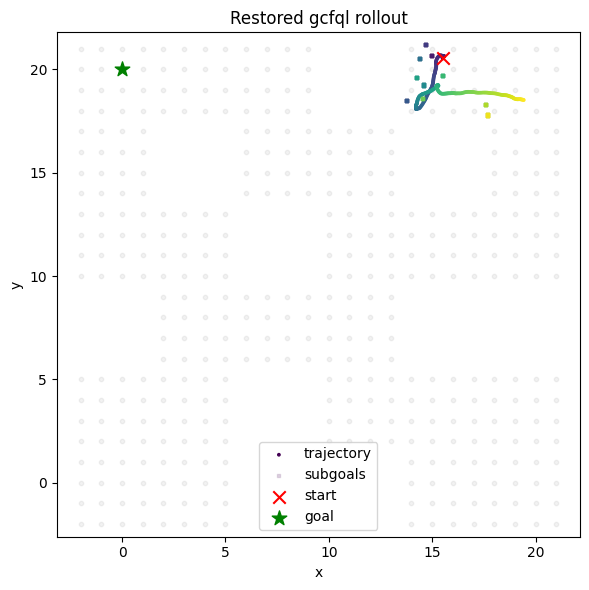

In [36]:
if traj_obs.shape[-1] >= 2:
    plt.figure(figsize=(6, 6))
    plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
    plt.scatter(traj_obs[:, 0], traj_obs[:, 1], marker='o', s=3, label='trajectory', cmap='viridis', c=np.arange(len(traj_obs)))
    plt.scatter(proposed_subgoals[:, 0], proposed_subgoals[:, 1], marker='s', alpha=0.15, s=5, label='subgoals', cmap='viridis', c=np.arange(len(proposed_subgoals)))
    plt.scatter(traj_obs[0, 0], traj_obs[0, 1], c='red', marker='x', s=80, label='start')
    plt.scatter(goal[0], goal[1], c='green', marker='*', s=120, label='goal')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Restored gcfql rollout')
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Observation does not have at least 2 dims to plot.')

In [37]:
rollout_steps = 250
subgoal_rollout_steps = 25
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0
subgoal = None

rng = jax.random.PRNGKey(seed)

for trial in tqdm(range(num_trials)):
    rng, _ = jax.random.split(rng)
    observation, info = env.reset(options=dict(task_id=task_id))
    goal = info.get('goal')
    if goal is None:
        raise ValueError('Environment reset did not return a goal.')
    if 'oracle_reps' in example_batch:
        goal = goal[: example_batch['oracle_reps'].shape[-1]]
        
    for step in tqdm(range(rollout_steps)):
        if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05 or subgoal_steps == subgoal_rollout_steps:
            subgoal_steps = 0
            rng, sample_rng = jax.random.split(rng)
            subgoal = flow_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None], sample_rng)[0]

        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))
        subgoal_steps += 1

        next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

        observation = next_observation
        # if terminated or truncated:
        #     print(f'rollout ended at step {step + 1}')
        #     break

        if observation[1] < goal_y:
            num_successes += 1
            break

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('num_breakouts:', num_successes)
print('breakout_rate:', num_successes / num_trials)

100%|██████████| 20/20 [00:18<00:00,  1.06it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
num_breakouts: 0
breakout_rate: 0.0


In [38]:
rollout_steps = 250
subgoal_rollout_steps = 25
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0
subgoal = None

rng = jax.random.PRNGKey(seed)

for trial in tqdm(range(num_trials)):
    rng, _ = jax.random.split(rng)
    observation, info = env.reset(options=dict(task_id=task_id))
    goal = info.get('goal')
    if goal is None:
        raise ValueError('Environment reset did not return a goal.')
    if 'oracle_reps' in example_batch:
        goal = goal[: example_batch['oracle_reps'].shape[-1]]
        
    for step in tqdm(range(rollout_steps)):
        if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05 or subgoal_steps == subgoal_rollout_steps:
            subgoal_steps = 0
            rng, sample_rng = jax.random.split(rng)
            subgoal = agent.sample_actions(to_oracle_reps(observation[None], env), goal[None])[0]

        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))
        subgoal_steps += 1

        next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

        observation = next_observation
        # if terminated or truncated:
        #     print(f'rollout ended at step {step + 1}')
        #     break

        if observation[1] < goal_y:
            num_successes += 1
            break

print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
print('num_breakouts:', num_successes)
print('breakout_rate:', num_successes / num_trials)

100%|██████████| 20/20 [00:18<00:00,  1.06it/s]

restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250
num_breakouts: 0
breakout_rate: 0.0


## Learn the Differences Instead of the Subgoals Themselves

In [39]:
delta_config = dict(config)
delta_config.update(
    observations_key='oracle_reps',
    goal_key='actor_goals',
    actions_key='low_actor_goals',
    hidden_dims=(256, 256, 256), # (64, 64),
    lr=3e-4,
    batch_size=256,
    num_train_steps=5000,
    log_interval=100,
)

class GCDeltaAgent(flax.struct.PyTreeNode):
    rng: Any
    network: TrainState
    config: Any = nonpytree_field()

    def delta_loss(self, batch, grad_params=None):
        observations = batch[self.config['observations_key']]
        goals = batch[self.config['goal_key']]
        target_actions = batch[self.config['actions_key']]
        target_deltas = target_actions - observations

        pred_deltas = self.network(observations, goals, params=grad_params)
        pred_actions = observations + pred_deltas

        delta_loss = jnp.mean(jnp.square(pred_deltas - target_deltas))
        action_mse = jnp.mean(jnp.square(pred_actions - target_actions))
        action_mae = jnp.mean(jnp.abs(pred_actions - target_actions))
        return delta_loss, {
            'delta_loss': delta_loss,
            'action_mse': action_mse,
            'action_mae': action_mae,
        }

    @jax.jit
    def update(self, batch):
        new_rng, _ = jax.random.split(self.rng)

        def loss_fn(grad_params):
            return self.delta_loss(batch, grad_params)

        new_network, info = self.network.apply_loss_fn(loss_fn)
        info['step'] = new_network.step
        return self.replace(rng=new_rng, network=new_network), info

    @jax.jit
    def sample_actions(self, observations, goals):
        single_example = observations.ndim == 1
        if single_example:
            observations = observations[None, ...]
            goals = goals[None, ...]

        pred_deltas = self.network(observations, goals)
        pred_actions = observations + pred_deltas
        return pred_actions[0] if single_example else pred_actions

    @classmethod
    def create(cls, example_batch, config):
        rng = jax.random.PRNGKey(config['seed'])
        rng, init_rng = jax.random.split(rng)
        action_dim = example_batch[config['actions_key']].shape[-1]
        model = GCMLPPolicy(
            hidden_dims=tuple(config['hidden_dims']),
            action_dim=action_dim,
            layer_norm=config['layer_norm'],
        )
        params = model.init(
            init_rng,
            example_batch[config['observations_key']],
            example_batch[config['goal_key']],
        )['params']
        network = TrainState.create(model, params, tx=optax.adam(config['lr']))
        return cls(rng=rng, network=network, config=flax.core.FrozenDict(config))

In [40]:
delta_agent = GCDeltaAgent.create(example_batch, delta_config)
delta_loss_history = []
delta_action_mse_history = []
delta_action_mae_history = []

for step in range(1, delta_config['num_train_steps'] + 1):
    batch = train_dataset.sample(delta_config['batch_size'])
    delta_agent, info = delta_agent.update(batch)

    delta_loss_history.append(float(info['delta_loss']))
    delta_action_mse_history.append(float(info['action_mse']))
    delta_action_mae_history.append(float(info['action_mae']))

    if step == 1 or step % delta_config['log_interval'] == 0:
        print(
            f"step={step:05d} delta_loss={delta_loss_history[-1]:.6f} "
            f"action_mse={delta_action_mse_history[-1]:.6f} "
            f"action_mae={delta_action_mae_history[-1]:.6f}"
        )

eval_batch = train_dataset.sample(8)
pred_actions = np.asarray(
    delta_agent.sample_actions(
        eval_batch[delta_config['observations_key']],
        eval_batch[delta_config['goal_key']],
    )
)
target_actions = np.asarray(eval_batch[delta_config['actions_key']])

print('delta model sample mse:', np.mean((pred_actions - target_actions) ** 2))

step=00001 delta_loss=1.188318 action_mse=1.188318 action_mae=0.866819
step=00100 delta_loss=0.598376 action_mse=0.598376 action_mae=0.631624
step=00200 delta_loss=0.655976 action_mse=0.655976 action_mae=0.628903
step=00300 delta_loss=0.514873 action_mse=0.514873 action_mae=0.559896
step=00400 delta_loss=0.509551 action_mse=0.509551 action_mae=0.567786
step=00500 delta_loss=0.508821 action_mse=0.508821 action_mae=0.553800
step=00600 delta_loss=0.501801 action_mse=0.501801 action_mae=0.533283
step=00700 delta_loss=0.477121 action_mse=0.477121 action_mae=0.536152
step=00800 delta_loss=0.455977 action_mse=0.455977 action_mae=0.535372
step=00900 delta_loss=0.523393 action_mse=0.523393 action_mae=0.556873
step=01000 delta_loss=0.453551 action_mse=0.453551 action_mae=0.514622
step=01100 delta_loss=0.480651 action_mse=0.480651 action_mae=0.528419
step=01200 delta_loss=0.517256 action_mse=0.517256 action_mae=0.554749
step=01300 delta_loss=0.472194 action_mse=0.472194 action_mae=0.537418
step=0

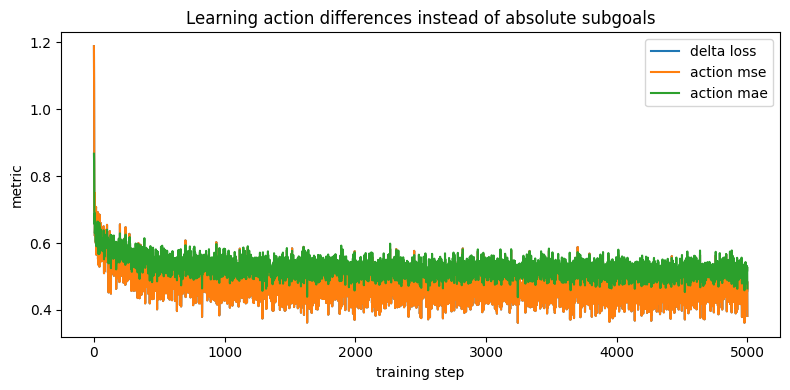

In [41]:
plt.figure(figsize=(8, 4))
plt.plot(delta_loss_history, label='delta loss')
plt.plot(delta_action_mse_history, label='action mse')
plt.plot(delta_action_mae_history, label='action mae')
plt.xlabel('training step')
plt.ylabel('metric')
plt.title('Learning action differences instead of absolute subgoals')
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
replay_buffer = []
ob = np.asarray([15.0, 12.0])
goal = np.asarray([0.0, 0.0])
rng = jax.random.PRNGKey(delta_config['seed'])

for s in range(200):
    replay_buffer.append(ob.copy())
    pred_delta = np.asarray(
        delta_agent.network(
            ob[None, ...],
            goal[None, ...],
        )[0]
    )
    subgoal = ob + pred_delta
    # print('delta:', pred_delta, 'subgoal:', subgoal)

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached fixed point at step {s}')
        break

    ob = subgoal

reached fixed point at step 35


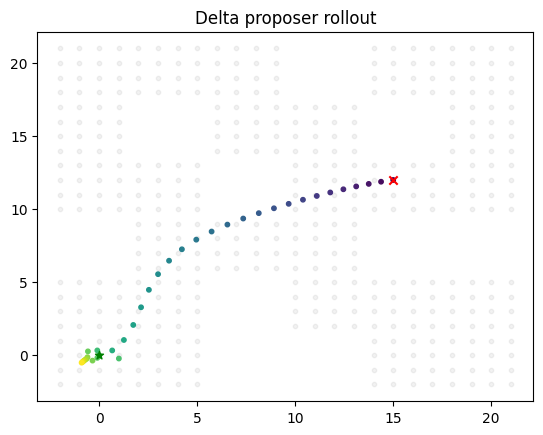

In [43]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Delta proposer rollout')
plt.show()

In [44]:
replay_buffer = []
ob = np.asarray([15.0, 12.0])
goal = np.asarray([0.0, 0.0])
rng = jax.random.PRNGKey(delta_config['seed'])

for s in range(200):
    replay_buffer.append(ob.copy())
    pred_delta = np.asarray(
        agent.network(
            ob[None, ...],
            goal[None, ...],
        )[0]
    )
    subgoal = pred_delta
    # print('delta:', pred_delta, 'subgoal:', subgoal)

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached fixed point at step {s}')
        break

    ob = subgoal

reached fixed point at step 21


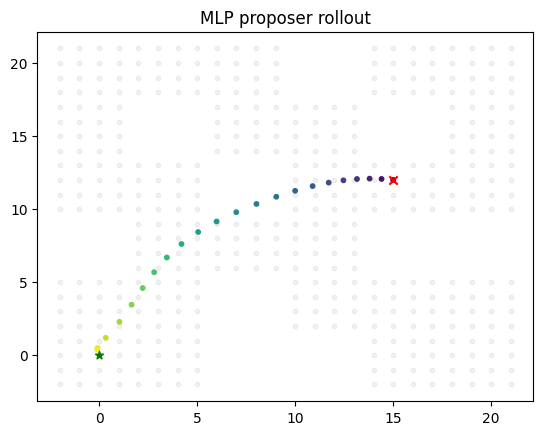

In [45]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('MLP proposer rollout')
plt.show()

All else being equal, learning the difference doesn't matter.

reached at step 179!
subgoal: [-0.42355537  2.656331  ]


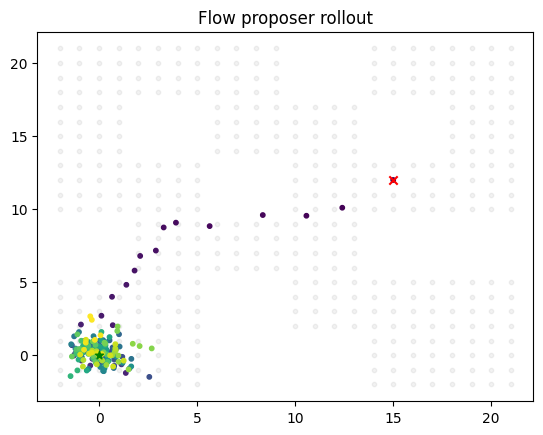

In [46]:
replay_buffer = []
ob = np.asarray([15.0, 12.0])
goal = np.asarray([0.0, 0.0])
rng = jax.random.PRNGKey(config['seed'])

for s in range(200):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

In [47]:
replay_buffer = []
ob = np.asarray([14.5, 20.0])
goal = np.asarray([11.0, 8.0])
rng = jax.random.PRNGKey(delta_config['seed'])

for s in range(200):
    replay_buffer.append(ob.copy())

    subgoal = np.asarray(
        agent.network(
            ob[None, ...],
            goal[None, ...],
        )[0]
    )

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached fixed point at step {s}')
        rng, subkey = jax.random.split(rng)
        noise = np.asarray(jax.random.normal(subkey, shape=ob.shape)) * 0.1
        ob = ob + noise
        print(f'adding: {noise}')
    else:
        ob = subgoal

reached fixed point at step 50
adding: [-0.24424557 -0.20356806]
reached fixed point at step 53
adding: [-0.12574776 -0.04016044]
reached fixed point at step 56
adding: [-0.13877682  0.07748543]
reached fixed point at step 58
adding: [-0.23022664  0.0052778 ]
reached fixed point at step 61
adding: [-0.10147804  0.15873006]
reached fixed point at step 64
adding: [-0.01981789  0.07955903]
reached fixed point at step 66
adding: [-0.03021937 -0.1139671 ]
reached fixed point at step 67
adding: [-0.07427701  0.09748424]
reached fixed point at step 69
adding: [-0.0200383  -0.01144468]
reached fixed point at step 70
adding: [-0.03177674  0.00737342]
reached fixed point at step 72
adding: [-0.08475428  0.0507578 ]
reached fixed point at step 74
adding: [-0.02507795 -0.07602494]
reached fixed point at step 76
adding: [0.1830863  0.04328811]
reached fixed point at step 78
adding: [-0.15585093 -0.0787986 ]
reached fixed point at step 79
adding: [0.13490531 0.04142695]
reached fixed point at step 8

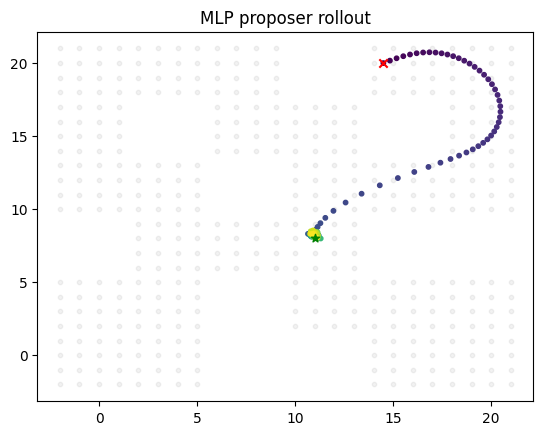

In [48]:
replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('MLP proposer rollout')
plt.show()

reached at step 44!
subgoal: [11.441569  8.345326]


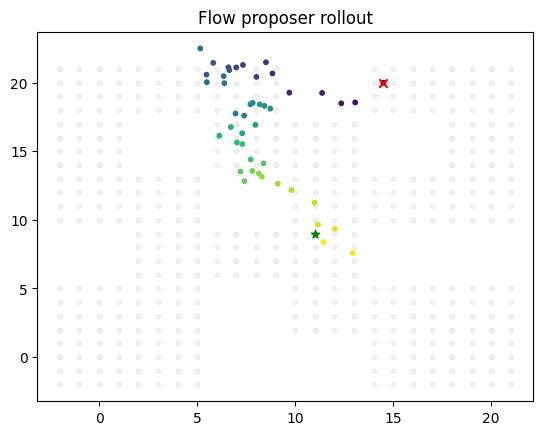

In [ ]:
replay_buffer = []
ob = np.asarray([14.5, 20.0])
goal = np.asarray([11.0, 9.0])
rng = jax.random.PRNGKey(config['seed'])

for s in range(200):
    replay_buffer.append(ob)
    rng, sample_rng = jax.random.split(rng)
    subgoal = np.asarray(flow_agent.sample_actions(ob, goal, sample_rng))

    if np.linalg.norm(subgoal - ob) < 0.05:
        print(f'reached at step {s}!')
        print('subgoal:', subgoal)
        break
    else:
        ob = subgoal

replay_buffer = np.asarray(replay_buffer)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.title('Flow proposer rollout')
plt.show()

## REINFORCE Stage

In [50]:
from wrappers.datafuncs_utils import to_oracle_reps

reinforce_config = dict(
    lr=1e-4,
    seed=0,
    num_updates=200,
    episodes_per_update=16,
    controller_horizon=25,
    reach_threshold=0.75,
    baseline_momentum=0.9,
    proposal_std=0.75,
    task_id=1,
)

def gaussian_log_prob(sample, mean, std):
    z = (sample - mean) / std
    return -0.5 * jnp.sum(z ** 2 + 2.0 * jnp.log(std) + jnp.log(2.0 * jnp.pi), axis=-1)

def sample_subgoal_from_mlp(mlp_agent, observations, goals, rng, proposal_std):
    single_example = observations.ndim == 1
    if single_example:
        observations = observations[None, ...]
        goals = goals[None, ...]
    mean = mlp_agent.network(observations, goals)
    std = jnp.full_like(mean, proposal_std)
    noise = jax.random.normal(rng, mean.shape)
    sample = mean + noise * std
    log_prob = gaussian_log_prob(sample, mean, std)
    return (sample[0], log_prob[0]) if single_example else (sample, log_prob)

def reinforce_update_mlp(mlp_agent, batch, lr, proposal_std):
    tx = optax.adam(lr)
    network = mlp_agent.network.replace(tx=tx, opt_state=tx.init(mlp_agent.network.params))

    def loss_fn(grad_params):
        mean = network(batch['observations'], batch['goals'], params=grad_params)
        std = jnp.full_like(mean, proposal_std)
        log_prob = gaussian_log_prob(batch['subgoals'], mean, std)
        loss = -(batch['advantages'] * log_prob).mean()
        return loss, {
            'loss': loss,
            'reward_mean': batch['rewards'].mean(),
            'adv_mean': batch['advantages'].mean(),
            'log_prob': log_prob.mean(),
        }

    new_network, info = network.apply_loss_fn(loss_fn)
    return mlp_agent.replace(network=new_network), info

def rollout_to_subgoal(mlp_agent, env, gcfql_agent, config, rng):
    observation, info = env.reset(options=dict(task_id=config['task_id']))
    final_goal = info.get('goal')
    if final_goal is None:
        raise ValueError('Environment reset did not return a goal.')

    obs_rep = np.asarray(to_oracle_reps(np.asarray(observation)[None], env=env))[0]
    goal_rep = np.asarray(final_goal[: obs_rep.shape[-1]])

    rng, sample_rng = jax.random.split(rng)
    subgoal, log_prob = sample_subgoal_from_mlp(
        mlp_agent,
        obs_rep,
        goal_rep,
        sample_rng,
        config['proposal_std'],
    )
    subgoal = np.asarray(subgoal)
    log_prob = float(log_prob)

    reached = False
    min_dist = np.inf
    curr_observation = observation
    for _ in range(config['controller_horizon']):
        rng, action_rng = jax.random.split(rng)
        action = np.asarray(gcfql_agent.sample_actions(observations=curr_observation, goals=subgoal, seed=action_rng))
        next_observation, _, terminated, truncated, _ = env.step(np.clip(action, -1, 1))
        next_rep = np.asarray(to_oracle_reps(np.asarray(next_observation)[None], env=env))[0]
        dist = float(np.linalg.norm(next_rep - subgoal))
        min_dist = min(min_dist, dist)
        curr_observation = next_observation
        if dist <= config['reach_threshold']:
            reached = True
            break
        if terminated or truncated:
            break

    reward = 1.0 if reached else 0.0
    return {
        'observations': obs_rep,
        'goals': goal_rep,
        'subgoals': subgoal,
        'rewards': reward,
        'log_prob': log_prob,
        'min_dist': min_dist,
        'reached': reached,
    }, rng

reinforce_agent = agent

baseline = 0.0
reward_history = []
distance_history = []
log_prob_history = []
rng = jax.random.PRNGKey(reinforce_config['seed'])

for update_idx in range(1, reinforce_config['num_updates'] + 1):
    episodes = []
    for _ in range(reinforce_config['episodes_per_update']):
        episode, rng = rollout_to_subgoal(reinforce_agent, env, gcfql_agent, reinforce_config, rng)
        episodes.append(episode)

    rewards = np.asarray([episode['rewards'] for episode in episodes], dtype=np.float32)
    min_dists = np.asarray([episode['min_dist'] for episode in episodes], dtype=np.float32)
    log_probs = np.asarray([episode['log_prob'] for episode in episodes], dtype=np.float32)
    baseline = reinforce_config['baseline_momentum'] * baseline + (1.0 - reinforce_config['baseline_momentum']) * float(rewards.mean())
    advantages = rewards - baseline

    batch = {
        'observations': jnp.asarray(np.stack([episode['observations'] for episode in episodes])),
        'goals': jnp.asarray(np.stack([episode['goals'] for episode in episodes])),
        'subgoals': jnp.asarray(np.stack([episode['subgoals'] for episode in episodes])),
        'rewards': jnp.asarray(rewards),
        'advantages': jnp.asarray(advantages),
    }
    reinforce_agent, info = reinforce_update_mlp(
        reinforce_agent,
        batch,
        reinforce_config['lr'],
        reinforce_config['proposal_std'],
    )

    reward_history.append(float(rewards.mean()))
    distance_history.append(float(min_dists.mean()))
    log_prob_history.append(float(log_probs.mean()))

    if update_idx == 1 or update_idx % 10 == 0:
        print(
            f"update={update_idx:04d} reward_mean={reward_history[-1]:.3f} "
            f"min_dist={distance_history[-1]:.3f} log_prob={log_prob_history[-1]:.3f} baseline={baseline:.3f}"
        )


update=0001 reward_mean=0.188 min_dist=1.460 log_prob=-2.379 baseline=0.019
update=0010 reward_mean=0.625 min_dist=0.846 log_prob=-2.014 baseline=0.188
update=0020 reward_mean=0.125 min_dist=1.772 log_prob=-2.566 baseline=0.226
update=0030 reward_mean=0.125 min_dist=1.633 log_prob=-2.528 baseline=0.305
update=0040 reward_mean=0.375 min_dist=0.941 log_prob=-2.309 baseline=0.288
update=0050 reward_mean=0.250 min_dist=0.984 log_prob=-2.252 baseline=0.286
update=0060 reward_mean=0.312 min_dist=1.076 log_prob=-2.411 baseline=0.265
update=0070 reward_mean=0.375 min_dist=1.197 log_prob=-2.287 baseline=0.293
update=0080 reward_mean=0.438 min_dist=0.939 log_prob=-2.340 baseline=0.295
update=0090 reward_mean=0.375 min_dist=1.063 log_prob=-2.525 baseline=0.324
update=0100 reward_mean=0.500 min_dist=1.017 log_prob=-2.151 baseline=0.343
update=0110 reward_mean=0.312 min_dist=1.050 log_prob=-2.423 baseline=0.325
update=0120 reward_mean=0.438 min_dist=0.753 log_prob=-1.855 baseline=0.335
update=0130 

KeyboardInterrupt: 

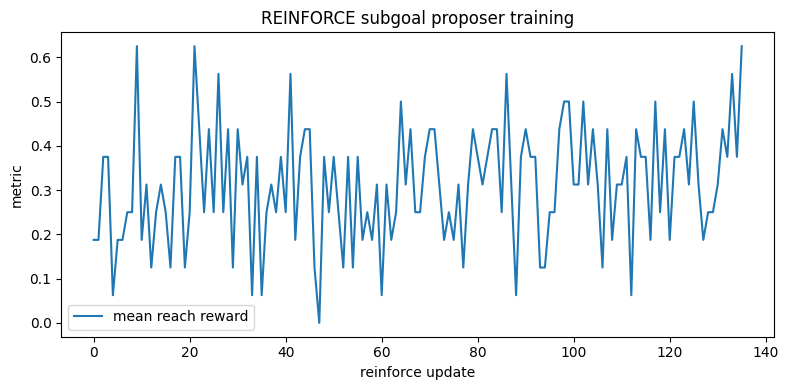

In [53]:
plt.figure(figsize=(8, 4))
plt.plot(reward_history, label='mean reach reward')
# plt.plot(distance_history, label='mean min distance')
# plt.plot(log_prob_history, label='mean sampled log prob')
plt.xlabel('reinforce update')
plt.ylabel('metric')
plt.title('REINFORCE subgoal proposer training')
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
eval_episode, rng = rollout_to_subgoal(reinforce_agent, env, gcfql_agent, reinforce_config, rng)
print(eval_episode)


{'observations': array([16.348728, 19.258078], dtype=float32), 'goals': array([ 0., 20.]), 'subgoals': array([16.340076, 21.194393], dtype=float32), 'rewards': 0.0, 'log_prob': -4.354447841644287, 'min_dist': 1.8013242483139038, 'reached': False}


100%|██████████| 5000/5000 [00:21<00:00, 232.09it/s]


restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250


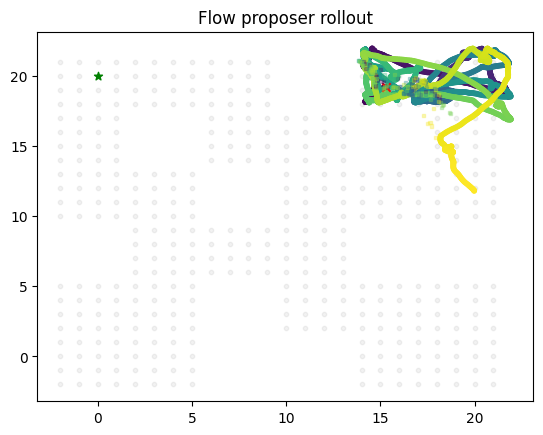

In [81]:
rollout_steps = 5000
subgoal_rollout_steps = 25
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0
subgoal = None

rng = jax.random.PRNGKey(seed)

# for trial in tqdm(range(num_trials)):
rng, _ = jax.random.split(rng)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

replay_buffer = [observation]
subgoals = []
    
for step in tqdm(range(rollout_steps)):
    if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05 or subgoal_steps == subgoal_rollout_steps:
        subgoal_steps = 0
        rng, sample_rng = jax.random.split(rng)
        subgoal = reinforce_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None])[0]
        subgoals.append(subgoal)

    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=subgoal, seed=action_rng))
    subgoal_steps += 1

    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

    observation = next_observation
    replay_buffer.append(observation)
    # if terminated or truncated:
    #     print(f'rollout ended at step {step + 1}')
    #     break

    if np.linalg.norm(observation[:2] - goal_y) < 0.05:
        num_successes += 1
        print('success!')
        break

replay_buffer = np.asarray(replay_buffer)
print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
# print('num_breakouts:', num_successes)
# print('breakout_rate:', num_successes / num_trials)

replay_buffer = np.asarray(replay_buffer)
subgoals = np.asarray(subgoals)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
plt.scatter(subgoals[:, 0], subgoals[:, 1], marker='s', alpha=0.3, s=5, label='subgoals', cmap='viridis', c=np.arange(len(subgoals)))
plt.title('Flow proposer rollout')
plt.show()

100%|██████████| 5000/5000 [00:17<00:00, 286.73it/s]


restored agent: gcfql
env: humanoidmaze-medium-navigate-singletask-task4-v0
dataset path: ../../scratch/data/humanoidmaze-medium-navigate-v0/humanoidmaze-medium-navigate-v0seed-42.npz
num steps: 250


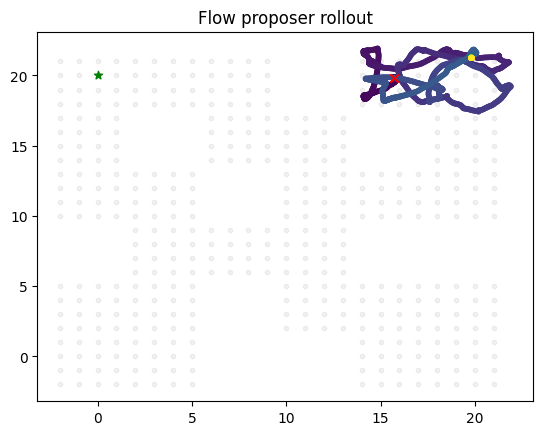

In [80]:
rollout_steps = 5000
subgoal_rollout_steps = 25
task_id = 1

goal_y = 15.0
num_trials = 20
num_successes = 0
subgoal = None

rng = jax.random.PRNGKey(seed)

# for trial in tqdm(range(num_trials)):
rng, _ = jax.random.split(rng)
observation, info = env.reset(options=dict(task_id=task_id))
goal = info.get('goal')
if goal is None:
    raise ValueError('Environment reset did not return a goal.')
if 'oracle_reps' in example_batch:
    goal = goal[: example_batch['oracle_reps'].shape[-1]]

replay_buffer = [observation]
subgoals = []
    
for step in tqdm(range(rollout_steps)):
    # if subgoal is None or np.linalg.norm(subgoal - observation[:2]) < 0.05 or subgoal_steps == subgoal_rollout_steps:
    #     subgoal_steps = 0
    #     rng, sample_rng = jax.random.split(rng)
    #     subgoal = reinforce_agent.sample_actions(to_oracle_reps(observation[None], env), goal[None])[0]
    #     subgoals.append(subgoal)

    rng, action_rng = jax.random.split(rng)
    action = np.asarray(gcfql_agent.sample_actions(observations=observation, goals=goal, seed=action_rng))
    subgoal_steps += 1

    next_observation, reward, terminated, truncated, info = env.step(np.clip(action, -1, 1))

    observation = next_observation
    replay_buffer.append(observation)
    # if terminated or truncated:
    #     print(f'rollout ended at step {step + 1}')
    #     break

    if np.linalg.norm(observation[:2] - goal_y) < 0.05:
        num_successes += 1
        print('success!')
        break

replay_buffer = np.asarray(replay_buffer)
print('restored agent:', gcfql_config['agent_name'])
print('env:', env_name)
print('dataset path:', dataset_path)
print('num steps:', len(traj_actions))
# print('num_breakouts:', num_successes)
# print('breakout_rate:', num_successes / num_trials)

replay_buffer = np.asarray(replay_buffer)
subgoals = np.asarray(subgoals)
plt.scatter(x=all_cell_points[..., 0], y=all_cell_points[..., 1], s=10, alpha=0.1, c='gray')
plt.scatter(x=replay_buffer[..., 0], y=replay_buffer[..., 1], c=np.arange(len(replay_buffer)), cmap='viridis', s=10)
plt.scatter(x=goal[0], y=goal[1], c='green', marker='*')
plt.scatter(x=replay_buffer[0][0], y=replay_buffer[0][1], marker='x', c='red')
# plt.scatter(subgoals[:, 0], subgoals[:, 1], marker='s', alpha=0.3, s=5, label='subgoals', cmap='viridis', c=np.arange(len(subgoals)))
plt.title('Flow proposer rollout')
plt.show()

## Trying in Humanoidmaze-large